imports


In [23]:
import os
import shutil
import json
import random
import cv2
import numpy as np
import pandas as pd

Paths

In [24]:
project_path = "D:\\VS CODE\\machine Learning\\deep learning\\yolo\\project4"

rawframes_path = os.path.join(project_path, "rawframes")
train_json_path = os.path.join(project_path, "imagenet_vid_train_15frames.json")
val_json_path = os.path.join(project_path, "imagenet_vid_val.json")

print(os.listdir(rawframes_path))

['benign', 'malignant']


Copy Images (Flatten Structure)

In [25]:
for cls in ["benign", "malignant"]:
    class_path = os.path.join(rawframes_path, cls)

    for video_folder in os.listdir(class_path):
        video_path = os.path.join(class_path, video_folder)

        for img in os.listdir(video_path):
            src = os.path.join(video_path, img)

            new_name = f"{video_folder}_{img}"  # avoid duplicates
            dst = os.path.join("dataset/images/train", new_name)

            shutil.copy(src, dst)

print("✅ Images copied!")

✅ Images copied!


Train/Val Split

In [26]:
images = os.listdir("dataset/images/train")

random.shuffle(images)

split = int(0.8 * len(images))

val_images = images[split:]

for img in val_images:
    src = os.path.join("dataset/images/train", img)
    dst = os.path.join("dataset/images/val", img)
    shutil.move(src, dst)

print("✅ Split done!")

✅ Split done!


In [27]:
print("Train:", len(os.listdir("dataset/images/train")))
print("Val:", len(os.listdir("dataset/images/val")))

Train: 12155
Val: 5475


Load JSON

In [28]:
with open(train_json_path, "r") as f:
    data = json.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['categories', 'videos', 'images', 'annotations'])


Inspect JSON

In [29]:
first_key = list(data.keys())[0]

print("First Key:", first_key)
print("\nSample Data:\n", data[first_key])

First Key: categories

Sample Data:
 [{'id': 1, 'name': 'benign', 'encode_name': 'benign'}, {'id': 2, 'name': 'malignant', 'encode_name': 'malignant'}]


Deep Inspection

In [30]:
if isinstance(data[first_key], list):
    print("First element:\n", data[first_key][0])
elif isinstance(data[first_key], dict):
    print("Inner keys:\n", data[first_key].keys())

First element:
 {'id': 1, 'name': 'benign', 'encode_name': 'benign'}


In [34]:
video_id_to_name = {}

for vid in data["videos"]:
    # remove 'benign/' or 'malignant/'
    clean_name = vid["name"].split("/")[-1]
    
    video_id_to_name[vid["id"]] = clean_name

print("✅ Clean video mapping created")

✅ Clean video mapping created


In [35]:
image_id_to_filename = {}

for img in data["images"]:
    video_id = img["video_id"]
    frame_id = img["frame_id"]

    video_name = video_id_to_name.get(video_id)

    filename = f"{video_name}_{str(frame_id).zfill(6)}.png"

    image_id_to_filename[img["id"]] = filename

print("✅ FINAL mapping created")

✅ FINAL mapping created


label generation

In [36]:
count_train = 0
count_val = 0

for ann in data["annotations"]:
    image_id = ann["image_id"]
    bbox = ann["bbox"]
    category_id = ann["category_id"] - 1

    filename = image_id_to_filename.get(image_id)

    if filename is None:
        continue

    # decide train or val
    if os.path.exists(os.path.join("dataset/images/train", filename)):
        split = "train"
    elif os.path.exists(os.path.join("dataset/images/val", filename)):
        split = "val"
    else:
        continue

    image_path = os.path.join(f"dataset/images/{split}", filename)

    img = cv2.imread(image_path)
    if img is None:
        continue

    h_img, w_img, _ = img.shape
    x, y, w, h = bbox

    if w <= 0 or h <= 0:
        continue

    x_c = (x + w / 2) / w_img
    y_c = (y + h / 2) / h_img
    w_n = w / w_img
    h_n = h / h_img

    label_file = os.path.join(f"dataset/labels/{split}", filename.replace(".png", ".txt"))

    with open(label_file, "a") as f:
        f.write(f"{category_id} {x_c} {y_c} {w_n} {h_n}\n")

    if split == "train":
        count_train += 1
    else:
        count_val += 1

print("✅ Train labels:", count_train)
print("✅ Val labels:", count_val)

✅ Train labels: 10666
✅ Val labels: 2586


In [37]:
print("Train images:", len(os.listdir("dataset/images/train")))
print("Train labels:", len(os.listdir("dataset/labels/train")))

print("Val images:", len(os.listdir("dataset/images/val")))
print("Val labels:", len(os.listdir("dataset/labels/val")))

Train images: 12155
Train labels: 10121
Val images: 5475
Val labels: 2468


In [38]:
import os

print(os.path.exists("D:/VS CODE/machine Learning/deep learning/yolo/project4/dataset/images/train"))
print(os.path.exists("D:/VS CODE/machine Learning/deep learning/yolo/project4/dataset/images/val"))

True
True


In [39]:
import torch
print(torch.cuda.is_available())

True


In [3]:
from ultralytics import YOLO
import torch

# FORCE GPU
device = "cuda:0"   # 🔥 IMPORTANT

print(torch.cuda.get_device_name(0))

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=384,
    batch=16,
    device=device,   # 🔥 FORCE RTX GPU
    workers=2,
    amp=True,
    cache=False,
    patience=20,
    cos_lr=True
)

NVIDIA GeForce RTX 4050 Laptop GPU
Ultralytics YOLOv8.2.0  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data.yaml, epochs=50, time=None, patience=20, batch=16, imgsz=384, save=True, save_period=-1, cache=False, device=cuda:0, workers=2, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False

train: Scanning D:\VS CODE\machine Learning\deep learning\yolo\project4\dataset\labels\train.cache... 16501 images, 3716 backgrounds, 0 corrupt: 100%|██████████| 20217/20217 [00:00<?, ?it/s]
val: Scanning D:\VS CODE\machine Learning\deep learning\yolo\project4\dataset\labels\val.cache... 4130 images, 925 backgrounds, 0 corrupt: 100%|██████████| 5055/5055 [00:00<?, ?it/s]


Plotting labels to runs\detect\train8\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 384 train, 384 val
Using 2 dataloader workers
Logging results to runs\detect\train8
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50      1.02G      1.413      2.181      1.374         14        384: 100%|██████████| 1264/1264 [03:05<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 158/158 [00:34<00:00,  4.62it/s]


                   all       5055       4322      0.619      0.637      0.632      0.385

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       5055       4322      0.891      0.985      0.985       0.79



50 epochs completed in 1.900 hours.
Optimizer stripped from runs\detect\train8\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\train8\weights\best.pt, 6.2MB

Validating runs\detect\train8\weights\best.pt...
Ultralytics YOLOv8.2.0  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 158/158 [00:24<00:00,  6.42it/s]


                   all       5055       4322      0.891      0.985      0.985       0.79
                benign       5055       1829      0.854      0.986      0.981      0.818
             malignant       5055       2493      0.928      0.985       0.99      0.762
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs\detect\train8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020AAE8227D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [40]:
from ultralytics import YOLO

model = YOLO("runs/detect/train8/weights/best.pt")

results = model.predict(
    source="dataset/images/val",
    conf=0.25,
    # save=True
)

c:\Users\arora\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, m



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/5475 d:\VS CODE\machine Learning\deep learning\yolo\project4\dataset\images\val\1165dd767cf0f4f3_000007.png: 384x384 (no detections), 9.2ms
image 2/5475 d:\VS CODE\machine Learning\deep learning\yolo\project4\dataset\images\val\1165dd767cf0f4f3_000008.png: 384x384 (no detections), 10.6ms
image 3/5475 d:\VS CODE\machine Learning\deep learning\yolo\project4\dataset\images\val\1165dd767cf0f4f3_000009.png: 384x384 (no detections), 6.6ms
image 4/5475 

KeyboardInterrupt: 

In [7]:
import cv2
import os

image_folder = "dataset/images/val"   # change if needed
images = sorted(os.listdir(image_folder))

frame = cv2.imread(os.path.join(image_folder, images[0]))
h, w, _ = frame.shape

video = cv2.VideoWriter("busi_video.mp4",
                        cv2.VideoWriter_fourcc(*'mp4v'),
                        5,
                        (w, h))

for img in images:
    path = os.path.join(image_folder, img)
    frame = cv2.imread(path)
    video.write(frame)

video.release()

print("✅ Video created: busi_video.mp4")

✅ Video created: busi_video.mp4


Extract Tumor Center

In [2]:
from ultralytics import YOLO
import cv2

model = YOLO("runs/detect/train8/weights/best.pt")

cap = cv2.VideoCapture("busi_video.avi")

positions = []

while True:
    ret, frame = cap.read()

    if not ret:
        print("End of video")
        break

    # 🔥 CRITICAL FIX
    frame = cv2.resize(frame, (384, 384))

    results = model(frame, conf=0.1)

    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            boxes = r.boxes.xyxy.cpu().numpy()

            x1, y1, x2, y2 = boxes[0]

            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            positions.append([cx, cy])

            print("Detected:", cx, cy)

    # visualize
    annotated = results[0].plot()
    cv2.imshow("Detection", annotated)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

print("Total points:", len(positions))

c:\Users\arora\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, m


0: 384x384 (no detections), 13.9ms
Speed: 7.5ms preprocess, 13.9ms inference, 2452.2ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 42.7ms
Speed: 3.6ms preprocess, 42.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 59.8ms
Speed: 4.0ms preprocess, 59.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 47.2ms
Speed: 1.9ms preprocess, 47.2ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 41.2ms
Speed: 1.7ms preprocess, 41.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 35.2ms
Speed: 1.8ms preprocess, 35.2ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 39.7ms
Speed: 1.1ms preprocess, 39.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 35.1ms
Speed: 1.7ms preprocess, 35.1m

BUILD MOTION DATASET

In [12]:
import numpy as np

positions = np.array(positions)

print("Original Shape:", positions.shape)

# normalize
positions[:, 0] /= 384
positions[:, 1] /= 384

SEQ_LEN = 20

X = []
y = []

for i in range(len(positions) - SEQ_LEN):

    seq = positions[i:i+SEQ_LEN]

    current_pos = positions[i+SEQ_LEN-1]

    next_pos = positions[i+SEQ_LEN]

    velocity = next_pos - current_pos

    X.append(seq)

    y.append(velocity)

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Original Shape: (1468, 2)
X Shape: (1448, 20, 2)
y Shape: (1448, 2)


Train LSTM

PyTorch Model

In [13]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=128,
            num_layers=3,
            batch_first=True,
            dropout=0.2
        )

        self.fc1 = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        return out

model = LSTMModel()

Training

In [14]:
import torch

# train test split
split = int(len(X) * 0.8)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

# tensor conversion
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.MSELoss()

EPOCHS = 100

train_losses = []
test_losses = []

for epoch in range(EPOCHS):

    model.train()

    output = model(X_train)

    loss = criterion(output, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        test_output = model(X_test)

        test_loss = criterion(test_output, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss.item():.6f}")
    print(f"Test Loss : {test_loss.item():.6f}")

Epoch 1
Train Loss: 0.005041
Test Loss : 0.002580
Epoch 2
Train Loss: 0.002581
Test Loss : 0.000960
Epoch 3
Train Loss: 0.000960
Test Loss : 0.000124
Epoch 4
Train Loss: 0.000127
Test Loss : 0.000103
Epoch 5
Train Loss: 0.000104
Test Loss : 0.000523
Epoch 6
Train Loss: 0.000524
Test Loss : 0.000606
Epoch 7
Train Loss: 0.000606
Test Loss : 0.000407
Epoch 8
Train Loss: 0.000408
Test Loss : 0.000182
Epoch 9
Train Loss: 0.000182
Test Loss : 0.000049
Epoch 10
Train Loss: 0.000049
Test Loss : 0.000012
Epoch 11
Train Loss: 0.000012
Test Loss : 0.000035
Epoch 12
Train Loss: 0.000035
Test Loss : 0.000080
Epoch 13
Train Loss: 0.000080
Test Loss : 0.000121
Epoch 14
Train Loss: 0.000121
Test Loss : 0.000144
Epoch 15
Train Loss: 0.000144
Test Loss : 0.000144
Epoch 16
Train Loss: 0.000143
Test Loss : 0.000124
Epoch 17
Train Loss: 0.000125
Test Loss : 0.000092
Epoch 18
Train Loss: 0.000092
Test Loss : 0.000056
Epoch 19
Train Loss: 0.000057
Test Loss : 0.000026
Epoch 20
Train Loss: 0.000026
Test Loss 

In [15]:
checkpoint = {

    'model_state_dict': model.state_dict(),

    'optimizer_state_dict': optimizer.state_dict(),

    'sequence_length': SEQ_LEN,

    'hidden_size': 128,

    'epochs': EPOCHS
}

torch.save(checkpoint, "lstm_checkpoint.pth")

print("✅ LSTM model saved successfully!")

✅ LSTM model saved successfully!


PREDICT FUTURE POSITION

In [16]:
def predict_next(model, sequence):

    model.eval()

    seq = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():

        pred_velocity = model(seq)

    return pred_velocity.numpy()[0]

VISUALIZATION

In [17]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np

# load YOLO
model_yolo = YOLO("runs/detect/train8/weights/best.pt")

# load LSTM
checkpoint = torch.load("lstm_checkpoint.pth")

model = LSTMModel()

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

# prediction function
def predict_next(model, sequence):

    seq = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():

        pred_velocity = model(seq)

    return pred_velocity.numpy()[0]

cap = cv2.VideoCapture("busi_video.avi")

# output video
out = cv2.VideoWriter(
    "ultra_bot_output.avi",
    cv2.VideoWriter_fourcc(*'MJPG'),
    5,
    (384, 384)
)

sequence = []

trajectory = []

frame_count = 0

# robotic needle initial position
needle_x = 192
needle_y = 192

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.resize(frame, (384, 384))

    frame_count += 1

    results = model_yolo(frame, conf=0.1)

    for r in results:

        if r.boxes is not None and len(r.boxes) > 0:

            boxes = r.boxes.xyxy.cpu().numpy()

            x1, y1, x2, y2 = boxes[0]

            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            # stronger fake motion
            cx += np.sin(frame_count / 5) * 15
            cy += np.cos(frame_count / 5) * 15

            # draw actual tumor center
            cv2.circle(frame,
                       (int(cx), int(cy)),
                       5,
                       (0,255,0),
                       -1)

            # normalized sequence
            sequence.append([cx/384, cy/384])

            trajectory.append((int(cx), int(cy)))

            trajectory = trajectory[-50:]

            # prediction
            if len(sequence) >= 20:

                seq_input = sequence[-20:]

                pred_vx, pred_vy = predict_next(model, seq_input)

                current_x = cx / 384
                current_y = cy / 384

                pred_x = current_x + pred_vx
                pred_y = current_y + pred_vy

                pred_x *= 384
                pred_y *= 384

                # predicted point
                cv2.circle(frame,
                           (int(pred_x), int(pred_y)),
                           5,
                           (0,0,255),
                           -1)

                # robotic needle movement
                needle_x += (pred_x - needle_x) * 0.15
                needle_y += (pred_y - needle_y) * 0.15

                # draw needle
                cv2.circle(frame,
                           (int(needle_x), int(needle_y)),
                           8,
                           (255,255,255),
                           -1)

                # line to target
                cv2.line(frame,
                         (int(needle_x), int(needle_y)),
                         (int(pred_x), int(pred_y)),
                         (255,0,0),
                         2)

    # trajectory
    for point in trajectory:

        cv2.circle(frame,
                   point,
                   2,
                   (0,255,255),
                   -1)

    out.write(frame)

    cv2.imshow("ULTRA-Bot", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()

out.release()

cv2.destroyAllWindows()

print("✅ Saved as ultra_bot_output.avi")

C:\Users\arora\AppData\Local\Temp\ipykernel_16320\4034167487.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("lstm_checkpoint.pth")



0: 384x384 (no detections), 16.4ms
Speed: 2.0ms preprocess, 16.4ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 14.1ms
Speed: 2.0ms preprocess, 14.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 16.5ms
Speed: 1.0ms preprocess, 16.5ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 13.5ms
Speed: 0.7ms preprocess, 13.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 13.2ms
Speed: 2.0ms preprocess, 13.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 12.0ms
Speed: 1.0ms preprocess, 12.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 13.0ms
Speed: 2.0ms preprocess, 13.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 384)

0: 384x384 (no detections), 12.2ms
Speed: 2.0ms preprocess, 12.2ms i

In [1]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
import time
import math

# ============================================================
# CONFIG
# ============================================================
VIDEO_PATH      = "busi_video.avi"
YOLO_WEIGHTS    = "runs/detect/train8/weights/best.pt"
LSTM_CHECKPOINT = "lstm_checkpoint.pth"
OUTPUT_PATH     = "ultra_bot_cinematic.avi"
FPS_OUT         = 10

# ── Layout ──────────────────────────────────────────────────
OUT_W, OUT_H = 1280, 720          # total output frame
SIDEBAR_W    = 290                # right dark panel width
VIDEO_W      = OUT_W - SIDEBAR_W  # 990 px for ultrasound

# ── Palette (BGR) ───────────────────────────────────────────
C_CYAN   = (255, 220,   0)   # teal/cyan accent
C_GREEN  = ( 55, 230,  55)   # tumor green
C_RED    = ( 50,  50, 220)   # prediction red
C_WHITE  = (240, 240, 240)   # needle white
C_YELLOW = ( 55, 210, 255)   # trajectory gold
C_GRAY   = (150, 150, 150)
C_DIM    = ( 70,  70,  70)
C_LABEL  = (200, 210, 220)
C_PANEL  = ( 12,  14,  18)   # sidebar bg
C_BORDER = ( 42,  48,  58)   # sidebar border line

FONT = cv2.FONT_HERSHEY_SIMPLEX

# ============================================================
# LOAD YOLO
# ============================================================
model_yolo = YOLO(YOLO_WEIGHTS)

# ============================================================
# LSTM MODEL
# ============================================================
class LSTMModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = torch.nn.LSTM(
            input_size=2, hidden_size=128, num_layers=3,
            batch_first=True, dropout=0.2,
        )
        self.fc1  = torch.nn.Linear(128, 64)
        self.relu = torch.nn.ReLU()
        self.fc2  = torch.nn.Linear(64, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc2(self.relu(self.fc1(out)))

checkpoint = torch.load(LSTM_CHECKPOINT, map_location="cpu")
model      = LSTMModel()
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ============================================================
# HELPERS
# ============================================================
def predict_next(model, sequence):
    seq = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        pred_velocity = model(seq)
    return pred_velocity.numpy()[0]

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def txt(img, text, org, scale=0.5, color=C_WHITE, thickness=1):
    cv2.putText(img, text, org, FONT, scale, color, thickness, cv2.LINE_AA)

def txt_shadow(img, text, org, scale=0.5, color=C_WHITE, thickness=1):
    """Text with a 1-px dark shadow for readability over video."""
    cv2.putText(img, text, (org[0]+1, org[1]+1), FONT, scale, (0,0,0), thickness+1, cv2.LINE_AA)
    cv2.putText(img, text, org,                   FONT, scale, color,    thickness,   cv2.LINE_AA)

def h_rule(img, x1, x2, y, color=C_BORDER, thickness=1):
    cv2.line(img, (x1, y), (x2, y), color, thickness, cv2.LINE_AA)

def corner_brackets(img, x1, y1, x2, y2, color, size=22, thickness=1):
    m = 0
    pts = [
        ((x1+m, y1+m), (x1+m+size, y1+m), (x1+m, y1+m+size)),
        ((x2-m, y1+m), (x2-m-size, y1+m), (x2-m, y1+m+size)),
        ((x1+m, y2-m), (x1+m+size, y2-m), (x1+m, y2-m-size)),
        ((x2-m, y2-m), (x2-m-size, y2-m), (x2-m, y2-m-size)),
    ]
    for corner, h_end, v_end in pts:
        cv2.line(img, corner, h_end, color, thickness, cv2.LINE_AA)
        cv2.line(img, corner, v_end, color, thickness, cv2.LINE_AA)

def dot_line(img, p1, p2, spacing=10, r=1, color=C_WHITE):
    x1, y1 = p1;  x2, y2 = p2
    dist = math.hypot(x2-x1, y2-y1)
    if dist < 1: return
    steps = max(1, int(dist // spacing))
    for i in range(steps+1):
        t = i / steps
        cv2.circle(img, (int(x1+(x2-x1)*t), int(y1+(y2-y1)*t)), r, color, -1, cv2.LINE_AA)

def target_rings(img, center, color, radii=(8, 13), thickness=1):
    for r in radii:
        cv2.circle(img, center, r, color, thickness, cv2.LINE_AA)

def fading_trail(img, pts, color=(55, 210, 255)):
    n = len(pts)
    if n < 2: return
    for i, p in enumerate(pts):
        a = (i+1) / n
        c = tuple(int(ch * a) for ch in color)
        cv2.circle(img, p, max(1, int(1 + a*2)), c, -1, cv2.LINE_AA)

def ecg_line(img, x0, y0, w=180, color=C_GREEN):
    """Draw a static ECG squiggle."""
    pts = np.array([
        [0, 0],[10,0],[16,-3],[21,6],[27,-14],[33,6],[40,0],
        [52,0],[58,-3],[64,-10],[70,3],[76,0],[85,-8],[92,0],[w,0]
    ])
    pts[:,0] = (pts[:,0] * w / pts[-1,0]).astype(int)
    pts[:,1] = pts[:,1]
    coords = np.column_stack([pts[:,0]+x0, pts[:,1]+y0]).reshape(-1,1,2).astype(np.int32)
    cv2.polylines(img, [coords], False, color, 1, cv2.LINE_AA)

def semi_rect(img, x1, y1, x2, y2, color=(0,0,0), alpha=0.55):
    """Dark semi-transparent fill for readability over video."""
    roi = img[y1:y2, x1:x2]
    overlay = np.full_like(roi, color)
    cv2.addWeighted(overlay, alpha, roi, 1-alpha, 0, roi)

# ============================================================
# SIDEBAR BUILDER
# ============================================================
def build_sidebar(status_color, fps, tumor_pt, pred_pt, needle_pt,
                  elapsed_s, tumor_found, frame_w=SIDEBAR_W, frame_h=OUT_H):
    """
    Returns a (frame_h × frame_w) BGR image for the right sidebar.
    All drawing happens on this opaque panel — no overlay on the video.
    """
    sb = np.full((frame_h, frame_w, 3), C_PANEL, dtype=np.uint8)

    # ── left border line ─────────────────────────────────────
    cv2.line(sb, (0, 0), (0, frame_h), C_BORDER, 1)

    sx = 24   # left margin inside sidebar

    # ── ULTRA-BOT logo ───────────────────────────────────────
    txt(sb, "ULTRA-BOT", (sx, 36), scale=0.82, color=(255,220,0), thickness=2)
    txt(sb, "AI GUIDED NEEDLE SYSTEM", (sx, 56), scale=0.36, color=(170,180,190), thickness=1)
    h_rule(sb, sx, frame_w-sx, 68)

    # ── STATUS ───────────────────────────────────────────────
    txt(sb, "STATUS", (sx, 98), scale=0.38, color=(120,220,120), thickness=1)
    txt(sb, "ACTIVE" if tumor_found else "SCANNING",
        (sx, 130), scale=0.90, color=C_GREEN if tumor_found else (60, 200, 255),
        thickness=2)

    # ECG
    ecg_line(sb, sx, 154, w=frame_w - sx*2,
             color=C_GREEN if tumor_found else (60,200,255))
    h_rule(sb, sx, frame_w-sx, 172)

    # ── MODEL ────────────────────────────────────────────────
    txt(sb, "MODEL", (sx, 200), scale=0.38, color=(210, 185, 60), thickness=1)
    txt(sb, "YOLOv8 + LSTM", (sx, 222), scale=0.52, color=C_WHITE, thickness=1)
    h_rule(sb, sx, frame_w-sx, 236)

    # ── MODE ─────────────────────────────────────────────────
    txt(sb, "MODE", (sx, 264), scale=0.38, color=(210, 185, 60), thickness=1)
    txt(sb, "TUMOR TRACKING",  (sx, 285), scale=0.46, color=C_WHITE, thickness=1)
    txt(sb, "NEEDLE GUIDANCE", (sx, 305), scale=0.46, color=C_WHITE, thickness=1)
    h_rule(sb, sx, frame_w-sx, 320)

    # ── COORDINATES readout ──────────────────────────────────
    txt(sb, "COORDINATES", (sx, 348), scale=0.38, color=(210, 185, 60), thickness=1)

    def coord_row(y, dot_color, label, pt):
        cv2.circle(sb, (sx+6, y-5), 5, dot_color, -1, cv2.LINE_AA)
        cv2.circle(sb, (sx+6, y-5), 5, C_WHITE, 1, cv2.LINE_AA)
        txt(sb, label, (sx+18, y), scale=0.38, color=(160,170,180), thickness=1)
        coord_str = f"({pt[0]}, {pt[1]})" if pt else "--"
        txt(sb, coord_str, (sx+18, y+16), scale=0.46, color=C_WHITE, thickness=1)

    coord_row(378, C_GREEN, "TUMOR CENTER",  tumor_pt  if tumor_found else None)
    coord_row(420, C_RED,   "PREDICTION",    pred_pt   if tumor_found else None)
    coord_row(462, C_WHITE, "NEEDLE TIP",    needle_pt if tumor_found else None)
    h_rule(sb, sx, frame_w-sx, 484)

    # ── LEGEND ───────────────────────────────────────────────
    txt(sb, "LEGEND", (sx, 510), scale=0.38, color=(210, 185, 60), thickness=1)

    def legend_item(y, dot_color, label, filled=True):
        if filled:
            cv2.circle(sb, (sx+8, y), 6, dot_color, -1, cv2.LINE_AA)
        else:
            cv2.circle(sb, (sx+8, y), 6, dot_color, 1, cv2.LINE_AA)
        txt(sb, label, (sx+22, y+5), scale=0.42, color=(200,210,220), thickness=1)

    legend_item(534, C_GREEN,  "TUMOR CENTER")
    legend_item(558, C_RED,    "PREDICTION")
    legend_item(582, C_WHITE,  "NEEDLE TIP",   filled=False)

    # dotted trajectory legend
    for i in range(6):
        a = (i+1)/6
        c = tuple(int(ch*a) for ch in C_YELLOW)
        cx_dot = sx + 4 + i*10
        cv2.circle(sb, (cx_dot, 607), 2, c, -1, cv2.LINE_AA)
    txt(sb, "TRAJECTORY", (sx+22, 611), scale=0.42, color=(200,210,220), thickness=1)

    h_rule(sb, sx, frame_w-sx, 626)

    # ── FPS + TIME ───────────────────────────────────────────
    mins = elapsed_s // 60;  secs = elapsed_s % 60
    txt(sb, f"FPS  {int(fps):>3}", (sx,     658), scale=0.46, color=C_GREEN, thickness=1)
    txt(sb, f"TIME  {mins:02}:{secs:02}", (sx+115, 658), scale=0.46, color=(255,220,0), thickness=1)

    return sb

# ============================================================
# VIDEO I/O
# ============================================================
cap = cv2.VideoCapture(VIDEO_PATH)
out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"MJPG"),
    FPS_OUT,
    (OUT_W, OUT_H),
)

# ============================================================
# STATE
# ============================================================
sequence      = []
trajectory    = []
needle_x      = float(VIDEO_W // 2)
needle_y      = float(OUT_H - 40)
frame_count   = 0
prev_time     = time.time()
last_pred_x   = VIDEO_W * 0.5
last_pred_y   = OUT_H  * 0.4

# ============================================================
# MAIN LOOP
# ============================================================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Resize video portion to VIDEO_W × OUT_H
    video = cv2.resize(frame, (VIDEO_W, OUT_H))
    frame_count += 1

    now      = time.time()
    fps      = 1.0 / max(1e-6, now - prev_time)
    prev_time = now
    elapsed  = int(frame_count / FPS_OUT)

    vh, vw = video.shape[:2]   # OUT_H, VIDEO_W

    # ── YOLO detection ──────────────────────────────────────
    results = model_yolo(video, conf=0.10, verbose=False)
    tumor_found = False
    cx = cy = None

    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            x1, y1, x2, y2 = r.boxes.xyxy.cpu().numpy()[0]
            cx = float((x1+x2)/2)
            cy = float((y1+y2)/2)
            tumor_found = True
            break

    tumor_pt  = None
    pred_pt   = None
    needle_pt = None

    # ── Detection-dependent drawing ─────────────────────────
    if tumor_found:
        # subtle sinusoidal jitter (demo motion)
        cx += math.sin(frame_count / 8.0) * 6.0
        cy += math.cos(frame_count / 7.0) * 6.0

        sequence.append([cx / vw, cy / vh])
        sequence  = sequence[-20:]
        trajectory.append((int(cx), int(cy)))
        trajectory = trajectory[-24:]

        if len(sequence) >= 20:
            pred_vx, pred_vy = predict_next(model, sequence[-20:])
            pred_x = clamp((cx/vw + float(pred_vx)) * vw, 0, vw-1)
            pred_y = clamp((cy/vh + float(pred_vy)) * vh, 0, vh-1)
            last_pred_x, last_pred_y = pred_x, pred_y

        needle_x += (last_pred_x - needle_x) * 0.10
        needle_y += (last_pred_y - needle_y) * 0.10

        tumor_center = (int(cx),       int(cy))
        pred_center  = (int(last_pred_x), int(last_pred_y))
        needle_tip   = (int(needle_x), int(needle_y))

        tumor_pt  = tumor_center
        pred_pt   = pred_center
        needle_pt = needle_tip

        # ── Trajectory trail (faint, on video) ──────────────
        fading_trail(video, trajectory, color=C_YELLOW)

        # ── Needle shaft (from bottom-left corner → tip) ────
        needle_origin = (20, vh - 10)
        cv2.line(video, needle_origin, needle_tip,
                 (210, 215, 220), 2, cv2.LINE_AA)

        # ── Dotted prediction line (tip → pred) ─────────────
        dot_line(video, needle_tip, pred_center,
                 spacing=10, r=1, color=(200, 205, 210))

        # ── Needle tip marker ────────────────────────────────
        cv2.circle(video, needle_tip, 5, C_WHITE, -1, cv2.LINE_AA)
        cv2.circle(video, needle_tip, 9, C_WHITE,  1, cv2.LINE_AA)

        # ── Tumor marker ─────────────────────────────────────
        cv2.circle(video, tumor_center, 6, C_GREEN, -1, cv2.LINE_AA)
        target_rings(video, tumor_center, C_GREEN, radii=(10, 15))

        # ── Prediction marker ────────────────────────────────
        cv2.circle(video, pred_center, 5, C_RED, -1, cv2.LINE_AA)
        target_rings(video, pred_center, C_RED, radii=(9, 14))

    # ── Top HUD bar on video (semi-transparent strip) ───────
    semi_rect(video, 0, 0, vw, 44, color=(0,0,0), alpha=0.55)
    txt_shadow(video, "ULTRA-BOT", (14, 30),
               scale=0.80, color=(255,220,0), thickness=2)
    txt_shadow(video, "GUIDED NEEDLE SYSTEM",
               (154, 30), scale=0.42, color=(190,200,210), thickness=1)
    txt_shadow(video, f"FPS  {int(fps)}",
               (vw - 100, 30), scale=0.52, color=C_GREEN, thickness=1)

    # ── Corner brackets on full video area ──────────────────
    corner_brackets(video, 6, 6, vw-6, vh-6, color=(0,220,255),
                    size=24, thickness=1)

    # ── Left readout labels (only when tracking) ────────────
    if tumor_found:
        readouts = [
            (C_GREEN, "TUMOR",      tumor_pt),
            (C_RED,   "PREDICTION", pred_pt),
            (C_WHITE, "NEEDLE TIP", needle_pt),
        ]
        base_y = 80
        for dot_c, label, pt in readouts:
            semi_rect(video, 14, base_y-20, 195, base_y+14,
                      color=(0,0,0), alpha=0.45)
            cv2.circle(video, (28, base_y-6), 5, dot_c, -1, cv2.LINE_AA)
            txt_shadow(video, label,
                       (40, base_y-4), scale=0.40,
                       color=(190,200,210), thickness=1)
            coord_str = f"({pt[0]}, {pt[1]})"
            txt_shadow(video, coord_str,
                       (40, base_y+10), scale=0.46,
                       color=C_WHITE, thickness=1)
            base_y += 52

    # ── Bottom TIME label on video ───────────────────────────
    semi_rect(video, 0, vh-34, 180, vh, color=(0,0,0), alpha=0.55)
    mins = elapsed // 60;  secs = elapsed % 60
    txt_shadow(video, "TIME", (14, vh-12),
               scale=0.42, color=(255,220,0), thickness=1)
    txt_shadow(video, f"{mins:02}:{secs:02}", (70, vh-12),
               scale=0.46, color=C_WHITE, thickness=1)

    # ── Build sidebar ────────────────────────────────────────
    sidebar = build_sidebar(
        status_color = C_GREEN if tumor_found else (60,200,255),
        fps          = fps,
        tumor_pt     = tumor_pt,
        pred_pt      = pred_pt,
        needle_pt    = needle_pt,
        elapsed_s    = elapsed,
        tumor_found  = tumor_found,
    )

    # ── Stitch video + sidebar side by side ─────────────────
    final = np.hstack([video, sidebar])

    out.write(final)
    cv2.imshow("ULTRA-BOT", final)

    if cv2.waitKey(1) & 0xFF == 27:
        break

# ============================================================
cap.release()
out.release()
cv2.destroyAllWindows()
print("✅  ULTRA-BOT output saved →", OUTPUT_PATH)

c:\Users\arora\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, m

✅  ULTRA-BOT output saved → ultra_bot_cinematic.avi


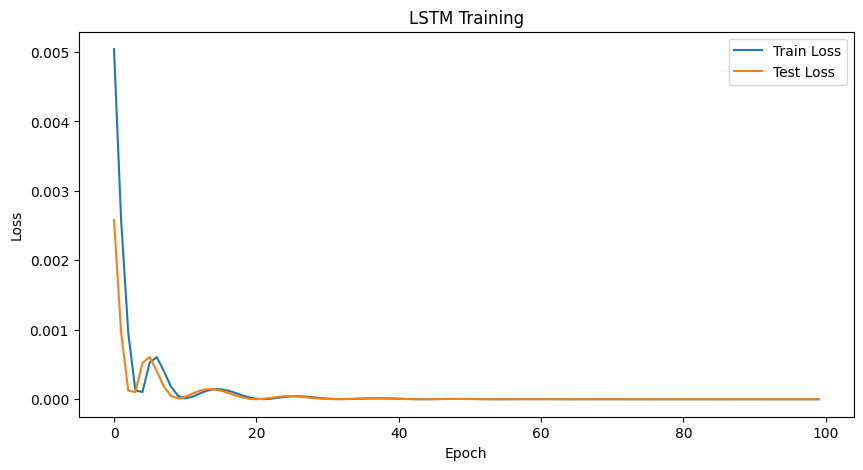

✅ Loss graph saved!


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("LSTM Training")

plt.legend()

plt.savefig("loss_graph.png")

plt.show()

print("✅ Loss graph saved!")

✅  Saved: ultrabot_trajectory.png
✅  Saved: ultrabot_trajectory.gif


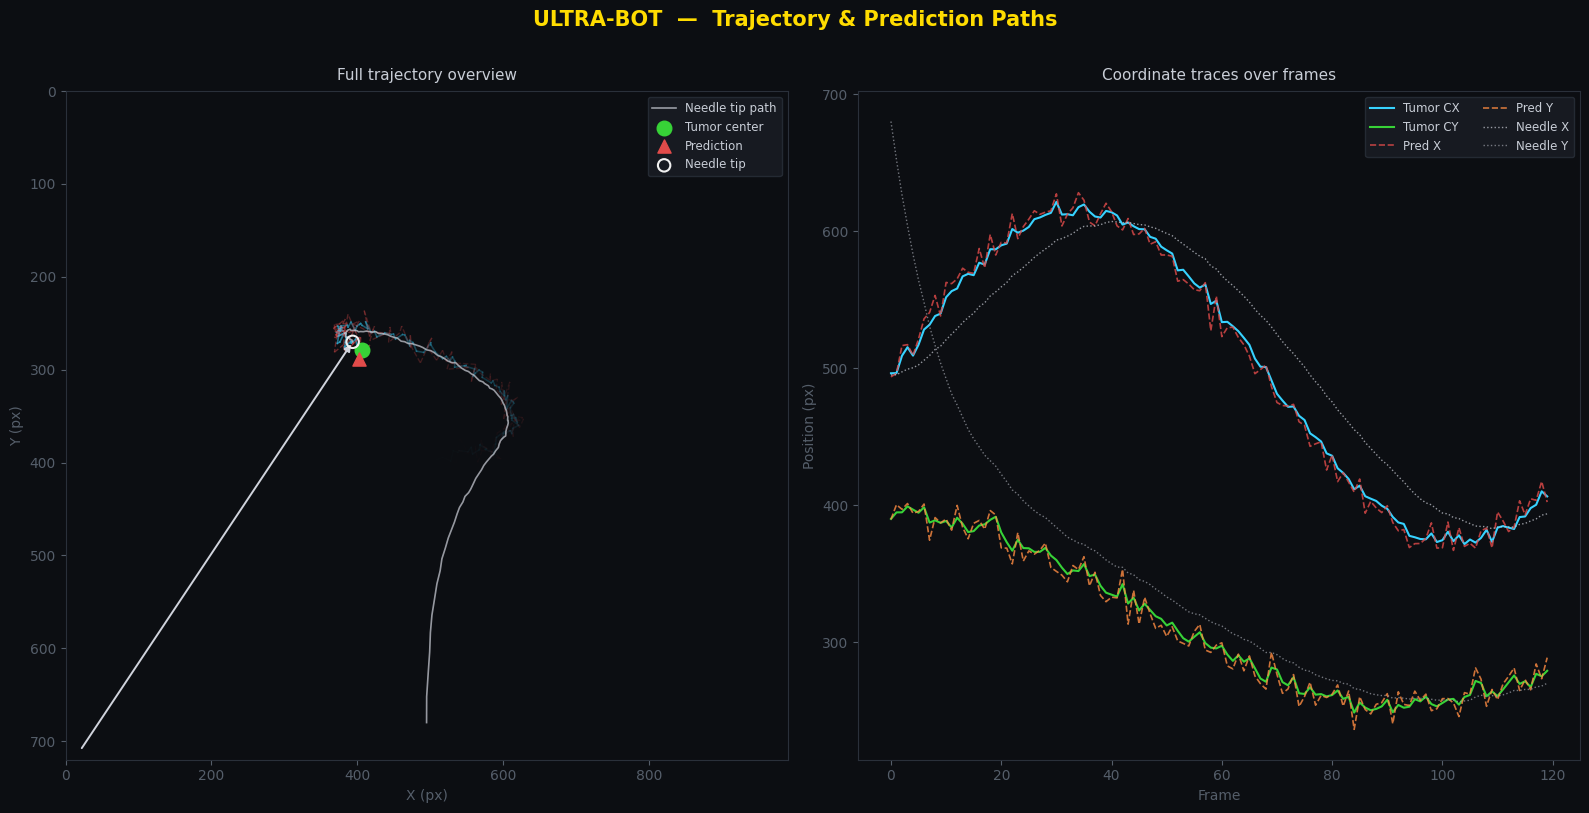

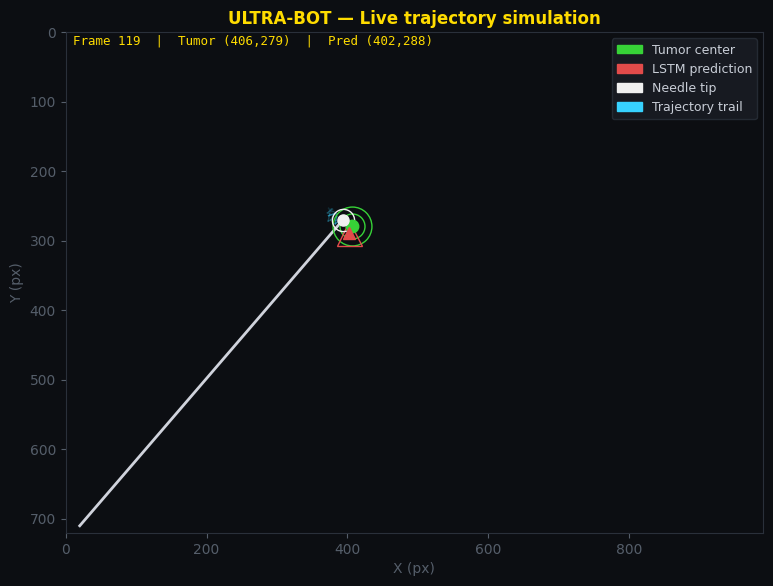

In [2]:
"""
ULTRA-BOT  —  Trajectory & Prediction Path Visualizer
======================================================
Simulates the tumor center motion, LSTM-predicted next position,
needle tip smoothing, and fading trail — exactly as the live system
draws them.  Saves:
  • ultrabot_trajectory.png  (static snapshot)
  • ultrabot_trajectory.gif  (animated, requires Pillow)

Run:
    pip install matplotlib numpy pillow
    python ultrabot_trajectory.py
"""

import math, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation, PillowWriter

# ── Reproducible simulation ──────────────────────────────────
rng = np.random.default_rng(42)

N_FRAMES    = 120
VW, VH      = 990, 720          # video canvas size (pixels)
TRAIL_LEN   = 24
SEQ_LEN     = 20

# ── Simulate tumor center (sinusoidal drift + small noise) ───
t       = np.linspace(0, 4 * math.pi, N_FRAMES)
cx_raw  = VW * 0.50 + 120 * np.sin(t / 2.3) + rng.normal(0, 4, N_FRAMES)
cy_raw  = VH * 0.45 +  70 * np.cos(t / 3.1) + rng.normal(0, 4, N_FRAMES)
cx_raw  = np.clip(cx_raw, 30, VW - 30)
cy_raw  = np.clip(cy_raw, 30, VH - 30)

# ── Simulate LSTM velocity predictions (slightly noisy) ──────
vx_true = np.diff(cx_raw / VW, prepend=cx_raw[0] / VW)
vy_true = np.diff(cy_raw / VH, prepend=cy_raw[0] / VH)
pred_vx = vx_true + rng.normal(0, 0.003, N_FRAMES)
pred_vy = vy_true + rng.normal(0, 0.003, N_FRAMES)

pred_x = np.clip((cx_raw / VW + pred_vx) * VW, 0, VW - 1)
pred_y = np.clip((cy_raw / VH + pred_vy) * VH, 0, VH - 1)

# ── Simulate needle tip (smoothed toward prediction) ─────────
needle_x = np.empty(N_FRAMES)
needle_y = np.empty(N_FRAMES)
needle_x[0] = VW / 2
needle_y[0] = VH - 40
for i in range(1, N_FRAMES):
    needle_x[i] = needle_x[i-1] + (pred_x[i] - needle_x[i-1]) * 0.10
    needle_y[i] = needle_y[i-1] + (pred_y[i] - needle_y[i-1]) * 0.10

# ════════════════════════════════════════════════════════════
# STATIC PLOT
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         facecolor="#0c0e12")
fig.suptitle("ULTRA-BOT  —  Trajectory & Prediction Paths",
             color="#ffdc00", fontsize=15, fontweight="bold", y=1.01)

AX_BG = "#0c0e12"
for ax in axes:
    ax.set_facecolor(AX_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a303a")

# ── Left panel: full trajectory overview ────────────────────
ax = axes[0]
ax.set_xlim(0, VW); ax.set_ylim(VH, 0)    # image coords (y flipped)
ax.set_title("Full trajectory overview", color="#c8cdd6", fontsize=11, pad=8)
ax.tick_params(colors="#555e6a")
ax.set_xlabel("X (px)", color="#555e6a")
ax.set_ylabel("Y (px)", color="#555e6a")

# Fading tumor trail
for i in range(1, N_FRAMES):
    alpha = (i / N_FRAMES) ** 1.4
    ax.plot(cx_raw[i-1:i+1], cy_raw[i-1:i+1],
            color="#37d2ff", alpha=alpha * 0.6, linewidth=1.2)

# Prediction trail
for i in range(1, N_FRAMES):
    alpha = (i / N_FRAMES) ** 1.4
    ax.plot(pred_x[i-1:i+1], pred_y[i-1:i+1],
            color="#e24b4a", alpha=alpha * 0.5, linewidth=1.0,
            linestyle="--")

# Needle path
ax.plot(needle_x, needle_y, color="#d0d3dc",
        linewidth=1.2, alpha=0.7, label="Needle tip path")

# Markers at final frame
ax.scatter(cx_raw[-1], cy_raw[-1], s=110, color="#37d237",
           zorder=6, label="Tumor center")
ax.scatter(pred_x[-1], pred_y[-1], s=90, color="#e24b4a",
           marker="^", zorder=6, label="Prediction")
ax.scatter(needle_x[-1], needle_y[-1], s=80, color="#f0f0f0",
           marker="o", facecolors="none", linewidths=1.5,
           zorder=6, label="Needle tip")

# Needle shaft line (origin → tip)
ax.annotate("", xy=(needle_x[-1], needle_y[-1]),
            xytext=(20, VH - 10),
            arrowprops=dict(arrowstyle="-|>", color="#d0d3dc",
                            lw=1.4, mutation_scale=10))

leg = ax.legend(facecolor="#1a1e26", edgecolor="#2a303a",
                labelcolor="#c8cdd6", fontsize=8.5, loc="upper right")

# ── Right panel: XY coordinate traces over time ─────────────
ax2 = axes[1]
ax2.set_facecolor(AX_BG)
for spine in ax2.spines.values():
    spine.set_edgecolor("#2a303a")
ax2.set_title("Coordinate traces over frames", color="#c8cdd6",
              fontsize=11, pad=8)
ax2.tick_params(colors="#555e6a")
ax2.set_xlabel("Frame", color="#555e6a")
ax2.set_ylabel("Position (px)", color="#555e6a")

frames = np.arange(N_FRAMES)
ax2.plot(frames, cx_raw,  color="#37d2ff", lw=1.5, label="Tumor CX")
ax2.plot(frames, cy_raw,  color="#37d237", lw=1.5, label="Tumor CY")
ax2.plot(frames, pred_x,  color="#e24b4a", lw=1.2,
         linestyle="--", alpha=0.8, label="Pred X")
ax2.plot(frames, pred_y,  color="#ff8c42", lw=1.2,
         linestyle="--", alpha=0.8, label="Pred Y")
ax2.plot(frames, needle_x, color="#d0d3dc", lw=1.0,
         linestyle=":", alpha=0.7, label="Needle X")
ax2.plot(frames, needle_y, color="#a0a3ac", lw=1.0,
         linestyle=":", alpha=0.7, label="Needle Y")

leg2 = ax2.legend(facecolor="#1a1e26", edgecolor="#2a303a",
                  labelcolor="#c8cdd6", fontsize=8.5, ncol=2)

plt.tight_layout()
plt.savefig("ultrabot_trajectory.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("✅  Saved: ultrabot_trajectory.png")

# ════════════════════════════════════════════════════════════
# ANIMATED GIF
# ════════════════════════════════════════════════════════════
fig2, ax3 = plt.subplots(figsize=(9, 6.5), facecolor="#0c0e12")
ax3.set_facecolor("#0c0e12")
for sp in ax3.spines.values():
    sp.set_edgecolor("#2a303a")
ax3.set_xlim(0, VW); ax3.set_ylim(VH, 0)
ax3.set_title("ULTRA-BOT — Live trajectory simulation",
              color="#ffdc00", fontsize=12, fontweight="bold")
ax3.tick_params(colors="#555e6a")
ax3.set_xlabel("X (px)", color="#555e6a")
ax3.set_ylabel("Y (px)", color="#555e6a")

# Static needle origin
needle_origin = (20, VH - 10)

# Artists
trail_lines = [ax3.plot([], [], color="#37d2ff", alpha=0, lw=1)[0]
               for _ in range(TRAIL_LEN)]
tumor_dot,    = ax3.plot([], [], "o", ms=9, color="#37d237", zorder=6)
tumor_ring1,  = ax3.plot([], [], "o", ms=18, mfc="none",
                          mec="#37d237", lw=1, zorder=5)
tumor_ring2,  = ax3.plot([], [], "o", ms=28, mfc="none",
                          mec="#37d237", lw=0.6, zorder=5)
pred_dot,     = ax3.plot([], [], "^", ms=9, color="#e24b4a", zorder=6)
pred_ring,    = ax3.plot([], [], "^", ms=18, mfc="none",
                          mec="#e24b4a", lw=1, zorder=5)
needle_dot,   = ax3.plot([], [], "o", ms=8, mfc="#f0f0f0",
                          mec="#f0f0f0", lw=1.5, zorder=6)
needle_ring,  = ax3.plot([], [], "o", ms=16, mfc="none",
                          mec="#f0f0f0", lw=1, zorder=5)
needle_line,  = ax3.plot([], [], color="#d0d3dc", lw=2)
dot_line_art, = ax3.plot([], [], ":", color="#c8cacc", lw=1, alpha=0.7)

legend_patches = [
    mpatches.Patch(color="#37d237", label="Tumor center"),
    mpatches.Patch(color="#e24b4a", label="LSTM prediction"),
    mpatches.Patch(color="#f0f0f0", label="Needle tip"),
    mpatches.Patch(color="#37d2ff", label="Trajectory trail"),
]
ax3.legend(handles=legend_patches, facecolor="#1a1e26",
           edgecolor="#2a303a", labelcolor="#c8cdd6",
           fontsize=9, loc="upper right")

frame_txt = ax3.text(10, 18, "", color="#ffdc00",
                     fontsize=9, fontfamily="monospace")

def update(f):
    # Trail
    start = max(0, f - TRAIL_LEN)
    pts   = list(zip(cx_raw[start:f+1], cy_raw[start:f+1]))
    for k, line in enumerate(trail_lines):
        idx = start + k
        if idx + 1 <= f and idx >= start:
            alpha = ((k + 1) / TRAIL_LEN) ** 1.3 * 0.7
            line.set_data([cx_raw[idx], cx_raw[idx+1]],
                          [cy_raw[idx], cy_raw[idx+1]])
            line.set_alpha(alpha)
        else:
            line.set_data([], [])

    tumor_dot.set_data([cx_raw[f]], [cy_raw[f]])
    tumor_ring1.set_data([cx_raw[f]], [cy_raw[f]])
    tumor_ring2.set_data([cx_raw[f]], [cy_raw[f]])

    pred_dot.set_data([pred_x[f]], [pred_y[f]])
    pred_ring.set_data([pred_x[f]], [pred_y[f]])

    needle_dot.set_data([needle_x[f]], [needle_y[f]])
    needle_ring.set_data([needle_x[f]], [needle_y[f]])
    needle_line.set_data([needle_origin[0], needle_x[f]],
                         [needle_origin[1], needle_y[f]])
    dot_line_art.set_data([needle_x[f], pred_x[f]],
                          [needle_y[f], pred_y[f]])

    frame_txt.set_text(f"Frame {f:03d}  |  "
                       f"Tumor ({int(cx_raw[f])},{int(cy_raw[f])})  |  "
                       f"Pred ({int(pred_x[f])},{int(pred_y[f])})")
    return (trail_lines + [tumor_dot, tumor_ring1, tumor_ring2,
            pred_dot, pred_ring, needle_dot, needle_ring,
            needle_line, dot_line_art, frame_txt])

ani = FuncAnimation(fig2, update, frames=N_FRAMES,
                    interval=80, blit=True)
ani.save("ultrabot_trajectory.gif",
         writer=PillowWriter(fps=12),
         dpi=100)
print("✅  Saved: ultrabot_trajectory.gif")
plt.show()

✅  Saved: ultrabot_lstm_architecture.png


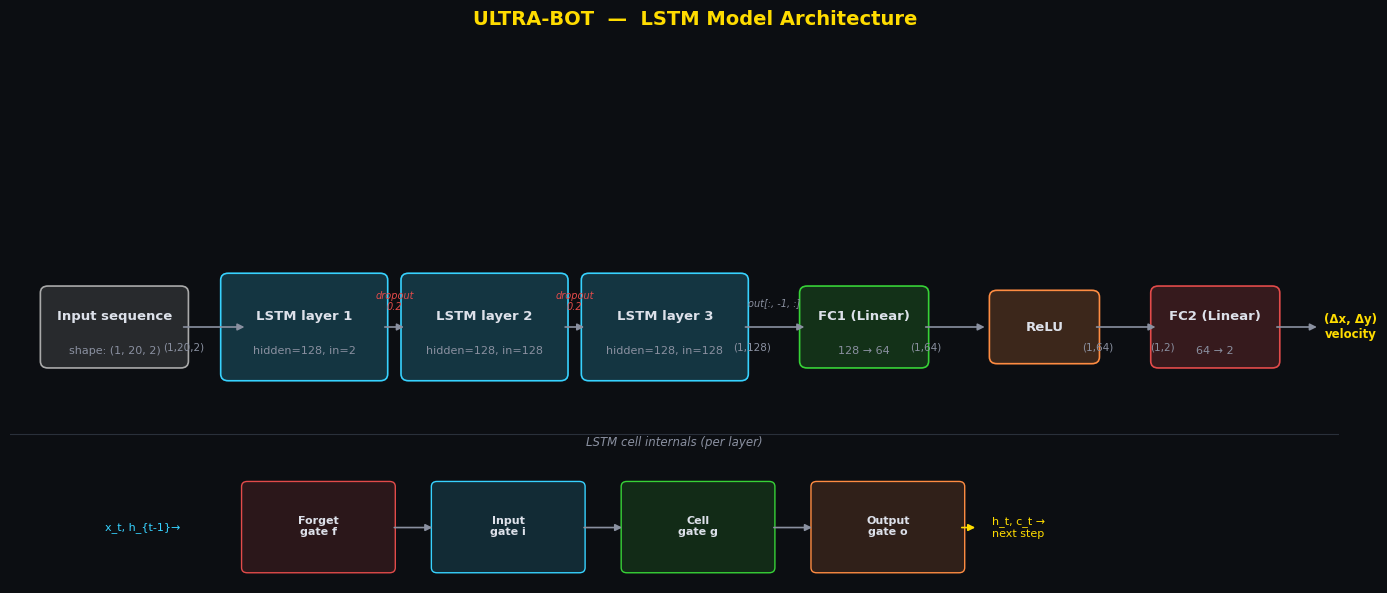

In [3]:
"""
ULTRA-BOT  —  LSTM Architecture Diagram
========================================
Draws the 3-layer LSTM → FC1 → ReLU → FC2 pipeline
as a clean schematic using matplotlib patches.

Run:
    pip install matplotlib numpy
    python ultrabot_lstm_diagram.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

BG    = "#0c0e12"
PANEL = "#12161f"
GOLD  = "#ffdc00"
CYAN  = "#37d2ff"
GREEN = "#37d237"
RED   = "#e24b4a"
GRAY  = "#8a90a0"
WHITE = "#dde1ea"

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 14); ax.set_ylim(0, 6)
ax.axis("off")
fig.suptitle("ULTRA-BOT  —  LSTM Model Architecture",
             color=GOLD, fontsize=14, fontweight="bold", y=0.98)

def box(ax, x, y, w, h, label, sublabel="", color=CYAN, alpha=0.18):
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.08",
                          facecolor=(*[c/255 for c in bytes.fromhex(
                              color.lstrip("#"))], alpha),
                          edgecolor=color, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x, y + (0.12 if sublabel else 0), label,
            ha="center", va="center",
            color=WHITE, fontsize=9.5, fontweight="bold")
    if sublabel:
        ax.text(x, y - 0.28, sublabel,
                ha="center", va="center",
                color=GRAY, fontsize=8)

def arrow(ax, x1, y1, x2, y2, color=GRAY):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=1.2, mutation_scale=10))

# ── Input ────────────────────────────────────────────────────
box(ax, 1.1, 3.0, 1.4, 0.8, "Input sequence",
    "shape: (1, 20, 2)", color="#aaaaaa")

arrow(ax, 1.8, 3.0, 2.5, 3.0)

# ── LSTM layers ──────────────────────────────────────────────
LSTM_XS = [3.1, 5.0, 6.9]
LSTM_LABELS = ["LSTM layer 1", "LSTM layer 2", "LSTM layer 3"]
LSTM_SUB    = ["hidden=128, in=2", "hidden=128, in=128", "hidden=128, in=128"]

for i, (lx, lbl, sub) in enumerate(zip(LSTM_XS, LSTM_LABELS, LSTM_SUB)):
    box(ax, lx, 3.0, 1.6, 1.1, lbl, sub, color=CYAN, alpha=0.20)
    if i < 2:
        arrow(ax, lx + 0.82, 3.0, LSTM_XS[i+1] - 0.82, 3.0)

# Dropout indicators between layers
for lx in LSTM_XS[:2]:
    mid = lx + 0.82 + (LSTM_XS[LSTM_XS.index(lx)+1] - lx - 1.64) / 2
    ax.text(mid, 3.30, "dropout\n0.2", ha="center", va="center",
            color=RED, fontsize=7, style="italic")

# ── Take last timestep ────────────────────────────────────────
arrow(ax, 7.72, 3.0, 8.4, 3.0)
ax.text(8.05, 3.24, "out[:, -1, :]", ha="center",
        color=GRAY, fontsize=7, style="italic")

# ── FC1 ──────────────────────────────────────────────────────
box(ax, 9.0, 3.0, 1.2, 0.8, "FC1 (Linear)",
    "128 → 64", color=GREEN, alpha=0.18)
arrow(ax, 9.62, 3.0, 10.3, 3.0)

# ── ReLU ─────────────────────────────────────────────────────
box(ax, 10.9, 3.0, 1.0, 0.7, "ReLU", "", color="#ff8c42", alpha=0.20)
arrow(ax, 11.42, 3.0, 12.1, 3.0)

# ── FC2 ──────────────────────────────────────────────────────
box(ax, 12.7, 3.0, 1.2, 0.8, "FC2 (Linear)",
    "64 → 2", color=RED, alpha=0.20)

# ── Output annotation ────────────────────────────────────────
arrow(ax, 13.32, 3.0, 13.8, 3.0)
ax.text(13.85, 3.0, "(Δx, Δy)\nvelocity",
        ha="left", va="center", color=GOLD,
        fontsize=8.5, fontweight="bold")

# ── Dimension annotations on arrows ─────────────────────────
dim_annots = [
    (1.83, 2.72, "(1,20,2)"),
    (7.82, 2.72, "(1,128)"),
    (9.65, 2.72, "(1,64)"),
    (11.46, 2.72, "(1,64)"),
    (12.14, 2.72, "(1,2)"),
]
for tx, ty, lbl in dim_annots:
    ax.text(tx, ty, lbl, ha="center", color=GRAY, fontsize=7.5)

# ── LSTM cell zoom (bottom) ──────────────────────────────────
ax.axhline(1.75, color="#2a303a", lw=0.8)
ax.text(7.0, 1.60, "LSTM cell internals (per layer)",
        ha="center", color=GRAY, fontsize=8.5, style="italic")

gates     = ["Forget\ngate f", "Input\ngate i", "Cell\ngate g", "Output\ngate o"]
gate_cols = [RED, CYAN, GREEN, "#ff8c42"]
gx_starts = [2.5, 4.5, 6.5, 8.5]

for gx, glabel, gc in zip(gx_starts, gates, gate_cols):
    rect = FancyBboxPatch((gx, 0.18), 1.5, 0.95,
                          boxstyle="round,pad=0.06",
                          facecolor=(*[c/255 for c in bytes.fromhex(
                              gc.lstrip("#"))], 0.15),
                          edgecolor=gc, linewidth=1.0)
    ax.add_patch(rect)
    ax.text(gx + 0.75, 0.66, glabel,
            ha="center", va="center",
            color=WHITE, fontsize=8, fontweight="bold")

# Arrows between gates
for i in range(3):
    arrow(ax, gx_starts[i] + 1.52, 0.65,
              gx_starts[i+1] - 0.02, 0.65, color=GRAY)

# Cell state bar
ax.annotate("", xy=(10.2, 0.65), xytext=(10.0, 0.65),
            arrowprops=dict(arrowstyle="-|>", color=GOLD, lw=1.2,
                            mutation_scale=10))
ax.text(10.35, 0.65, "h_t, c_t →\nnext step",
        ha="left", va="center", color=GOLD, fontsize=8)

# Input annotation
ax.text(1.8, 0.65, "x_t, h_{t-1}→", ha="right", va="center",
        color=CYAN, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("ultrabot_lstm_architecture.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
print("✅  Saved: ultrabot_lstm_architecture.png")
plt.show()

✅  Saved: ultrabot_pipeline.png


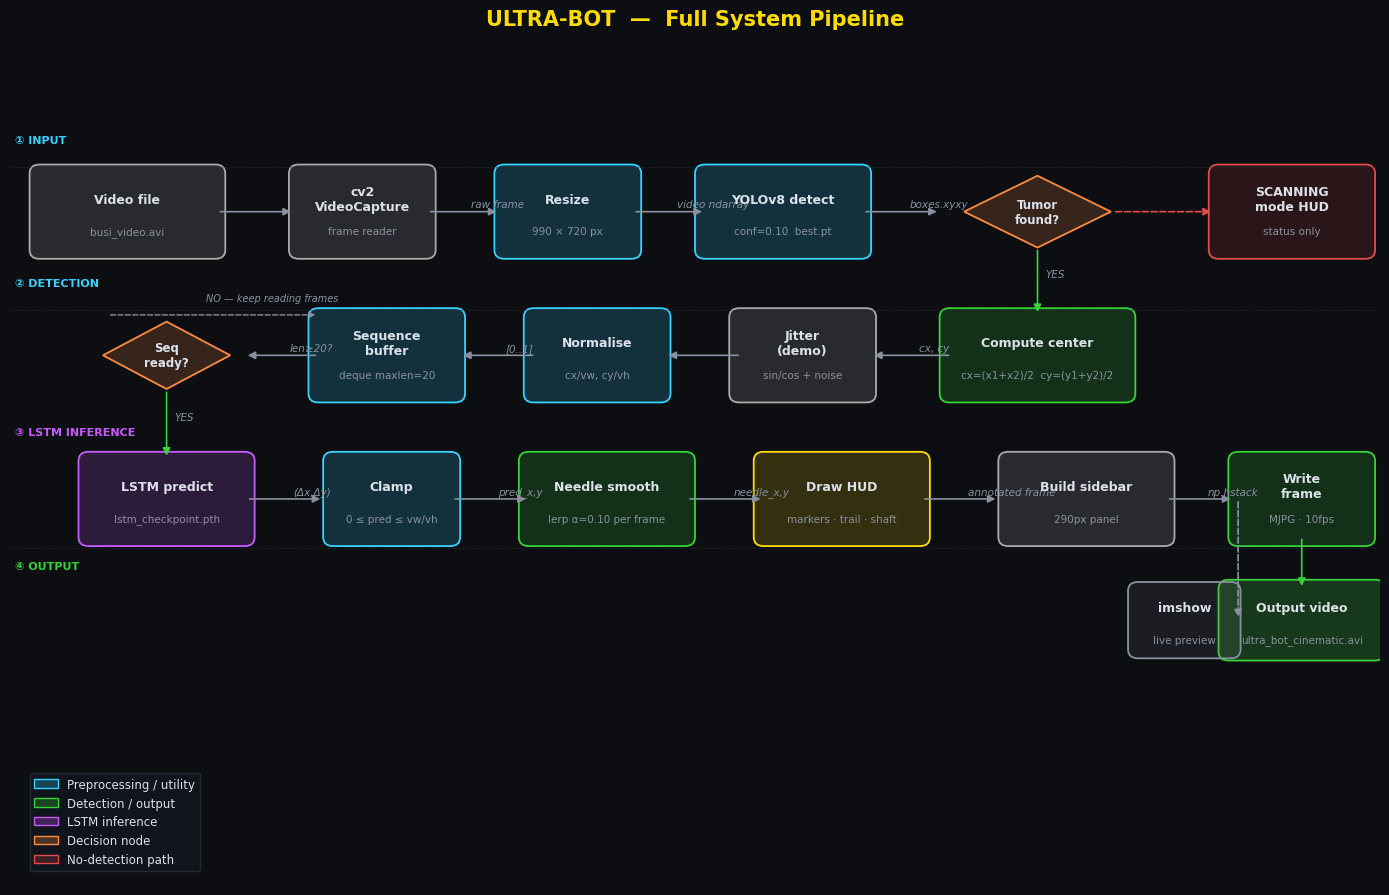

In [1]:
"""
ULTRA-BOT  —  System Pipeline Flowchart
=========================================
Draws the full end-to-end processing pipeline:
  Video Input → YOLO Detection → Sequence Buffer → LSTM Prediction
  → Needle Smoothing → HUD Overlay → Output Video

Run:
    pip install matplotlib numpy
    python ultrabot_pipeline.py
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ── Theme ────────────────────────────────────────────────────
BG    = "#0c0e12"
PANEL = "#12161f"
GOLD  = "#ffdc00"
CYAN  = "#37d2ff"
GREEN = "#37d237"
RED   = "#e24b4a"
GRAY  = "#8a90a0"
WHITE = "#dde1ea"
DIM   = "#2a303a"
ORANGE= "#ff8c42"

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis("off")
fig.suptitle("ULTRA-BOT  —  Full System Pipeline",
             color=GOLD, fontsize=15, fontweight="bold", y=0.99)

# ── Helpers ──────────────────────────────────────────────────
def hex_to_rgb01(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

def node(ax, x, y, w, h, title, subtitle="", color=CYAN, alpha=0.18,
         shape="round"):
    style = "round,pad=0.10" if shape == "round" else "square,pad=0.10"
    fc = (*hex_to_rgb01(color), alpha)
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=style,
                          facecolor=fc,
                          edgecolor=color, linewidth=1.3)
    ax.add_patch(rect)
    ty = y + (0.14 if subtitle else 0)
    ax.text(x, ty, title, ha="center", va="center",
            color=WHITE, fontsize=9, fontweight="bold")
    if subtitle:
        ax.text(x, y - 0.22, subtitle, ha="center", va="center",
                color=GRAY, fontsize=7.5)

def diamond(ax, x, y, w, h, label, color=ORANGE):
    dx, dy = w / 2, h / 2
    pts = [(x, y+dy), (x+dx, y), (x, y-dy), (x-dx, y)]
    poly = plt.Polygon(pts, closed=True,
                       facecolor=(*hex_to_rgb01(color), 0.18),
                       edgecolor=color, linewidth=1.3)
    ax.add_patch(poly)
    ax.text(x, y, label, ha="center", va="center",
            color=WHITE, fontsize=8.5, fontweight="bold")

def arrow(ax, x1, y1, x2, y2, color=GRAY, label="", lw=1.2,
          style="-|>", dash=False):
    ls = "--" if dash else "-"
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle=style, color=color,
                    lw=lw, mutation_scale=11,
                    linestyle=ls))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.08, my + 0.08, label,
                ha="left", va="center", color=GRAY, fontsize=7.5,
                style="italic")

def section_label(ax, x, y, text, color=GOLD):
    ax.text(x, y, text, ha="left", va="center",
            color=color, fontsize=8, fontweight="bold",
            bbox=dict(facecolor=BG, edgecolor="none", pad=1))

# ════════════════════════════════════════════════════════════
# MAIN PIPELINE  (left → right flow, two rows)
# ════════════════════════════════════════════════════════════

# ── Row 1 ────────────────────────────────────────────────────
#  [Video File] → [cv2.VideoCapture] → [Resize 990×720] → [YOLO v8]
node(ax,  1.2, 7.5, 1.8, 0.85, "Video file",
     "busi_video.avi", color="#aaaaaa")
arrow(ax, 2.12, 7.5, 2.9, 7.5)

node(ax,  3.6, 7.5, 1.3, 0.85, "cv2\nVideoCapture",
     "frame reader", color="#aaaaaa")
arrow(ax, 4.27, 7.5, 5.0, 7.5, label="raw frame")

node(ax,  5.7, 7.5, 1.3, 0.85, "Resize",
     "990 × 720 px", color=CYAN)
arrow(ax, 6.37, 7.5, 7.1, 7.5, label="video ndarray")

node(ax,  7.9, 7.5, 1.6, 0.85, "YOLOv8 detect",
     "conf=0.10  best.pt", color=CYAN)
arrow(ax, 8.72, 7.5, 9.5, 7.5, label="boxes.xyxy")

# Decision: tumor found?
diamond(ax, 10.5, 7.5, 1.5, 0.80, "Tumor\nfound?", color=ORANGE)

# YES path → down
arrow(ax, 10.5, 7.10, 10.5, 6.35, color=GREEN, label="YES")

# NO path → right
arrow(ax, 11.27, 7.5, 12.3, 7.5, color=RED, dash=True)
node(ax, 13.1, 7.5, 1.5, 0.85, "SCANNING\nmode HUD",
     "status only", color=RED, alpha=0.14)

# ── Row 2 ────────────────────────────────────────────────────
# [Compute cx,cy] → [Sinusoidal jitter] → [Normalise] → [Sequence buffer]
node(ax,  10.5, 5.9, 1.8, 0.85, "Compute center",
     "cx=(x1+x2)/2  cy=(y1+y2)/2", color=GREEN)
arrow(ax, 9.62, 5.9, 8.8, 5.9, label="cx, cy")

node(ax,  8.1, 5.9, 1.3, 0.85, "Jitter\n(demo)",
     "sin/cos + noise", color="#aaaaaa")
arrow(ax, 7.47, 5.9, 6.7, 5.9)

node(ax,  6.0, 5.9, 1.3, 0.85, "Normalise",
     "cx/vw, cy/vh", color=CYAN)
arrow(ax, 5.37, 5.9, 4.6, 5.9, label="[0..1]")

node(ax,  3.85, 5.9, 1.4, 0.85, "Sequence\nbuffer",
     "deque maxlen=20", color=CYAN)
arrow(ax, 3.15, 5.9, 2.4, 5.9, label="len≥20?")

diamond(ax, 1.6, 5.9, 1.3, 0.75, "Seq\nready?", color=ORANGE)

# YES path → down
arrow(ax, 1.6, 5.52, 1.6, 4.75, color=GREEN, label="YES")
# NO path (loop back — curved label)
ax.annotate("", xy=(3.15, 6.35), xytext=(1.0, 6.35),
            arrowprops=dict(arrowstyle="-|>", color=GRAY,
                            lw=1.0, linestyle="--",
                            connectionstyle="arc3,rad=0.0",
                            mutation_scale=9))
ax.text(2.0, 6.50, "NO — keep reading frames",
        color=GRAY, fontsize=7, style="italic")

# ── Row 3 ────────────────────────────────────────────────────
# [LSTM predict] → [Clamp] → [Needle smooth] → [Draw HUD] → [Write frame]
node(ax,  1.6, 4.3, 1.6, 0.85, "LSTM predict",
     "lstm_checkpoint.pth", color="#c85aff")
arrow(ax, 2.42, 4.3, 3.2, 4.3, label="(Δx,Δy)")

node(ax,  3.9, 4.3, 1.2, 0.85, "Clamp",
     "0 ≤ pred ≤ vw/vh", color=CYAN)
arrow(ax, 4.52, 4.3, 5.3, 4.3, label="pred_x,y")

node(ax,  6.1, 4.3, 1.6, 0.85, "Needle smooth",
     "lerp α=0.10 per frame", color=GREEN)
arrow(ax, 6.92, 4.3, 7.7, 4.3, label="needle_x,y")

node(ax,  8.5, 4.3, 1.6, 0.85, "Draw HUD",
     "markers · trail · shaft", color=GOLD, alpha=0.16)
arrow(ax, 9.32, 4.3, 10.1, 4.3, label="annotated frame")

node(ax, 11.0, 4.3, 1.6, 0.85, "Build sidebar",
     "290px panel", color="#aaaaaa")
arrow(ax, 11.82, 4.3, 12.5, 4.3, label="np.hstack")

node(ax, 13.2, 4.3, 1.3, 0.85, "Write\nframe",
     "MJPG · 10fps", color=GREEN)

# ── Down arrow from Draw HUD to sidebar ──────────────────────
# (already connected via arrow above)

# ── Final output arrow ───────────────────────────────────────
arrow(ax, 13.2, 3.88, 13.2, 3.3, color=GREEN)
node(ax, 13.2, 2.95, 1.5, 0.70, "Output video",
     "ultra_bot_cinematic.avi", color=GREEN, alpha=0.22)

# ── cv2.imshow side branch from Write ────────────────────────
arrow(ax, 12.55, 4.3, 12.55, 2.95, color=GRAY, dash=True)
node(ax, 12.0, 2.95, 0.95, 0.65, "imshow",
     "live preview", color=GRAY, alpha=0.12)

# ════════════════════════════════════════════════════════════
# SECTION LABELS
# ════════════════════════════════════════════════════════════
section_label(ax, 0.05, 8.30, "① INPUT", color=CYAN)
section_label(ax, 0.05, 6.70, "② DETECTION", color=CYAN)
section_label(ax, 0.05, 5.05, "③ LSTM INFERENCE", color="#c85aff")
section_label(ax, 0.05, 3.55, "④ OUTPUT", color=GREEN)

# horizontal dividers
for yy in [8.0, 6.4, 3.75]:
    ax.axhline(yy, color=DIM, lw=0.6, linestyle=":")

# ════════════════════════════════════════════════════════════
# LEGEND
# ════════════════════════════════════════════════════════════
legend_items = [
    mpatches.Patch(facecolor=(*hex_to_rgb01(CYAN),  0.25),
                   edgecolor=CYAN,  label="Preprocessing / utility"),
    mpatches.Patch(facecolor=(*hex_to_rgb01(GREEN), 0.25),
                   edgecolor=GREEN, label="Detection / output"),
    mpatches.Patch(facecolor=(*hex_to_rgb01("#c85aff"), 0.25),
                   edgecolor="#c85aff", label="LSTM inference"),
    mpatches.Patch(facecolor=(*hex_to_rgb01(ORANGE),0.25),
                   edgecolor=ORANGE, label="Decision node"),
    mpatches.Patch(facecolor=(*hex_to_rgb01(RED),   0.20),
                   edgecolor=RED,   label="No-detection path"),
]
leg = ax.legend(handles=legend_items, loc="lower left",
                facecolor="#12161f", edgecolor=DIM,
                labelcolor=WHITE, fontsize=8.5,
                bbox_to_anchor=(0.01, 0.01))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("ultrabot_pipeline.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
print("✅  Saved: ultrabot_pipeline.png")
plt.show()

✅  Saved: ultrabot_frame_layout.png


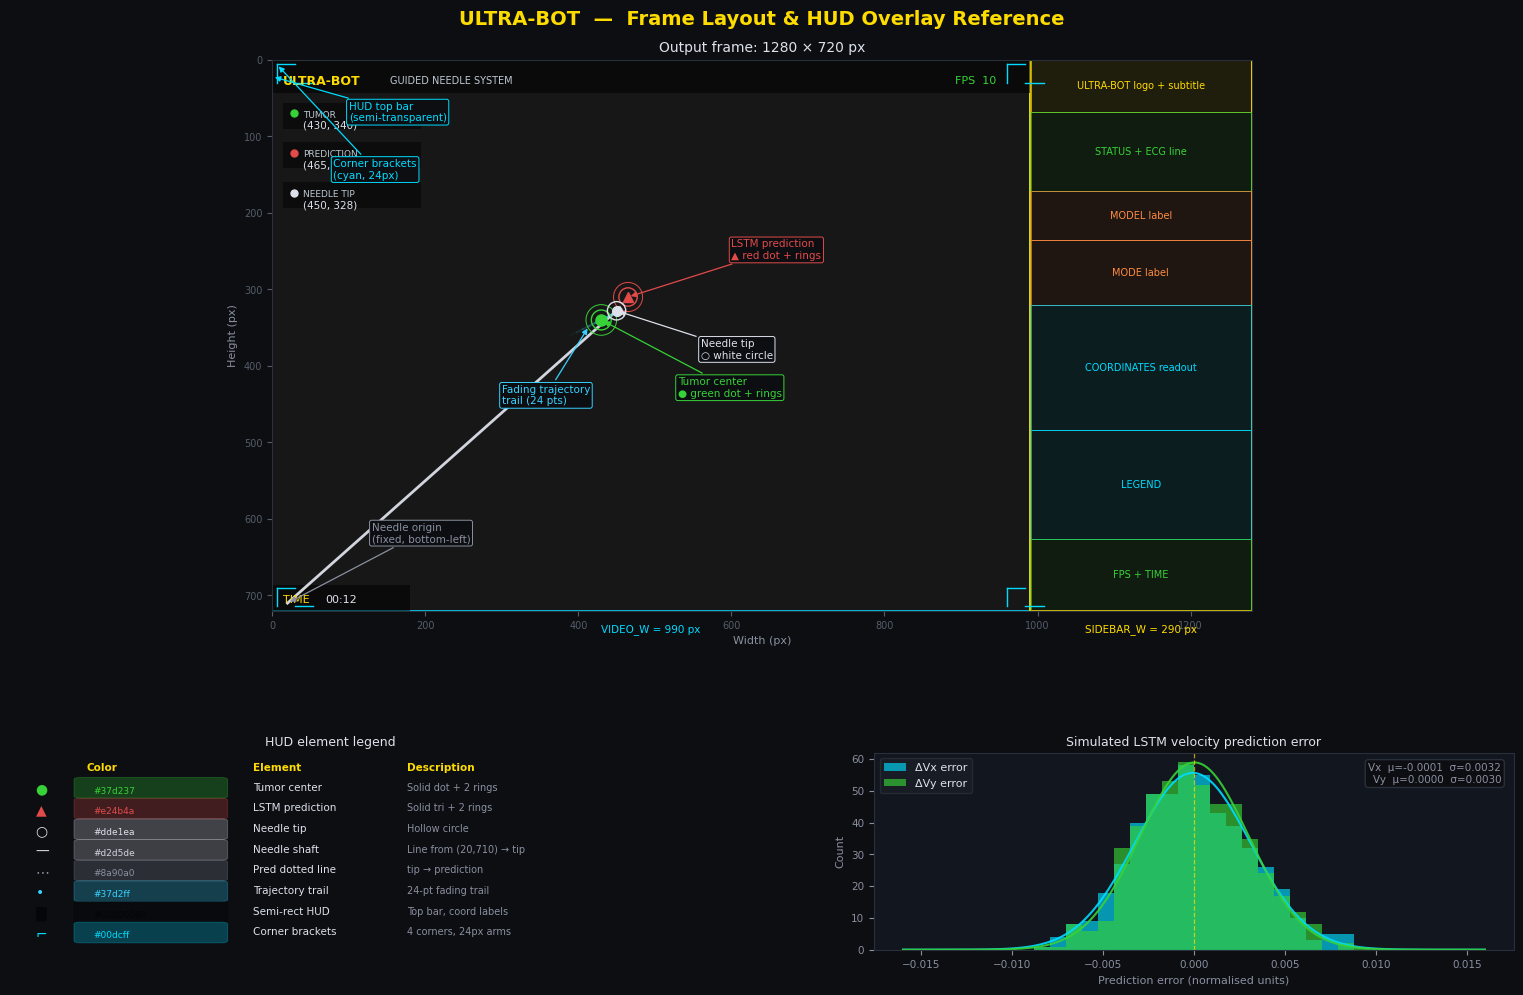

In [2]:
"""
ULTRA-BOT  —  Frame Layout & HUD Overlay Diagram
==================================================
Renders an annotated mock-up of the 1280×720 output frame showing:
  • Video panel (990px) with all overlays labelled
  • Sidebar panel (290px) with all UI sections labelled
  • Color-coded callout lines for every HUD element

Also produces a second chart: velocity error histogram comparing
simulated LSTM predictions vs ground-truth velocities.

Run:
    pip install matplotlib numpy
    python ultrabot_frame_layout.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

# ── Theme ────────────────────────────────────────────────────
BG    = "#0c0e12"
PANEL = "#12161f"
GOLD  = "#ffdc00"
CYAN  = "#00dcff"
GREEN = "#37d237"
RED   = "#e24b4a"
GRAY  = "#8a90a0"
WHITE = "#dde1ea"
DIM   = "#2a303a"
ORANGE= "#ff8c42"
YELLOW= "#37d2ff"   # trajectory (matches code C_YELLOW in BGR)

fig = plt.figure(figsize=(16, 10), facecolor=BG)

# ─── Layout: 2 rows, 3 cols ──────────────────────────────────
#   Top: full-width frame mockup
#   Bottom-left: legend table, Bottom-right: velocity error chart
gs = fig.add_gridspec(2, 2, height_ratios=[2.8, 1],
                      hspace=0.38, wspace=0.35,
                      left=0.03, right=0.97,
                      top=0.93, bottom=0.04)

ax_frame  = fig.add_subplot(gs[0, :])   # top — full width
ax_legend = fig.add_subplot(gs[1, 0])   # bottom left
ax_hist   = fig.add_subplot(gs[1, 1])   # bottom right

fig.suptitle("ULTRA-BOT  —  Frame Layout & HUD Overlay Reference",
             color=GOLD, fontsize=14, fontweight="bold")

# ════════════════════════════════════════════════════════════
# PANEL 1 — FRAME LAYOUT MOCKUP
# ════════════════════════════════════════════════════════════
ax = ax_frame
ax.set_facecolor("#101418")
ax.set_xlim(0, 1280); ax.set_ylim(720, 0)   # image coords
ax.set_aspect("equal")
ax.tick_params(colors="#555e6a", labelsize=7)
ax.set_xlabel("Width (px)", color=GRAY, fontsize=8)
ax.set_ylabel("Height (px)", color=GRAY, fontsize=8)
ax.set_title("Output frame: 1280 × 720 px", color=WHITE,
             fontsize=10, pad=6)
for sp in ax.spines.values():
    sp.set_edgecolor(DIM)

# ── Video region (0..990) ────────────────────────────────────
vid_rect = FancyBboxPatch((0, 0), 990, 720,
                          boxstyle="square,pad=0",
                          facecolor=(*[0.09]*3, 1),
                          edgecolor=CYAN, linewidth=1.2)
ax.add_patch(vid_rect)

# ── Sidebar region (990..1280) ───────────────────────────────
sb_rect = FancyBboxPatch((990, 0), 290, 720,
                         boxstyle="square,pad=0",
                         facecolor=(*[0.05]*3, 1),
                         edgecolor=GOLD, linewidth=1.2)
ax.add_patch(sb_rect)

# ── HUD top bar ──────────────────────────────────────────────
top_bar = FancyBboxPatch((0, 0), 990, 44,
                         boxstyle="square,pad=0",
                         facecolor=(0, 0, 0, 0.55),
                         edgecolor="none")
ax.add_patch(top_bar)
ax.text(14, 28, "ULTRA-BOT", color=GOLD, fontsize=9,
        fontweight="bold", va="center")
ax.text(154, 28, "GUIDED NEEDLE SYSTEM", color="#bec8d2",
        fontsize=7, va="center")
ax.text(892, 28, "FPS  10", color=GREEN, fontsize=8, va="center")

# ── Corner brackets ──────────────────────────────────────────
bracket_color = (0, 0.86, 1)
bsize = 24
corners = [(6, 6), (990-6-bsize, 6), (6, 720-6-bsize), (990-6-bsize, 720-6-bsize)]
for (bx, by) in corners:
    ax.plot([bx, bx+bsize], [by, by], color=bracket_color, lw=1)
    ax.plot([bx, bx], [by, by+bsize], color=bracket_color, lw=1)
    ax.plot([bx+bsize, bx+bsize*2], [by+bsize, by+bsize], color=bracket_color, lw=1)

# ── Tumor + rings ────────────────────────────────────────────
tx, ty = 430, 340
ax.plot(tx, ty, "o", ms=8, color=GREEN, zorder=6)
for r, lw in [(13, 1.0), (20, 0.7)]:
    circle = plt.Circle((tx, ty), r, fill=False, color=GREEN,
                         linewidth=lw, zorder=5)
    ax.add_patch(circle)

# ── Prediction + rings ───────────────────────────────────────
px2, py2 = 465, 310
ax.plot(px2, py2, "^", ms=7, color=RED, zorder=6)
for r, lw in [(12, 1.0), (19, 0.7)]:
    circle = plt.Circle((px2, py2), r, fill=False, color=RED,
                         linewidth=lw, zorder=5)
    ax.add_patch(circle)

# ── Needle tip + shaft ───────────────────────────────────────
nx, ny = 450, 328
ax.plot([20, nx], [710, ny], color="#d2d5de", lw=2)
ax.plot(nx, ny, "o", ms=7, color=WHITE, zorder=6)
circle = plt.Circle((nx, ny), 12, fill=False, color=WHITE,
                     linewidth=1.0, zorder=5)
ax.add_patch(circle)

# ── Dotted prediction line ───────────────────────────────────
xs = np.linspace(nx, px2, 10)
ys = np.linspace(ny, py2, 10)
ax.plot(xs, ys, ":", color="#c8cacc", lw=1.2, alpha=0.8)

# ── Trajectory trail ─────────────────────────────────────────
trail_pts = [(390+i*8, 360-i*4) for i in range(8)]
for i in range(1, len(trail_pts)):
    a = (i / len(trail_pts)) ** 1.3
    ax.plot([trail_pts[i-1][0], trail_pts[i][0]],
            [trail_pts[i-1][1], trail_pts[i][1]],
            color=YELLOW, alpha=a * 0.7, lw=1.5)

# ── Left readout block ───────────────────────────────────────
for j, (dot_c, lbl, val) in enumerate([
        (GREEN, "TUMOR",      "(430, 340)"),
        (RED,   "PREDICTION", "(465, 310)"),
        (WHITE, "NEEDLE TIP", "(450, 328)")]):
    by = 76 + j * 52
    ax.add_patch(FancyBboxPatch((14, by-20), 181, 34,
                                boxstyle="square,pad=0",
                                facecolor=(0,0,0,0.45),
                                edgecolor="none"))
    ax.plot(28, by-6, "o", ms=5, color=dot_c)
    ax.text(40, by-4,  lbl, color="#bec8d2", fontsize=6.5, va="center")
    ax.text(40, by+10, val, color=WHITE,     fontsize=7.5, va="center")

# ── Bottom time bar ──────────────────────────────────────────
ax.add_patch(FancyBboxPatch((0, 686), 180, 34,
                            boxstyle="square,pad=0",
                            facecolor=(0,0,0,0.55),
                            edgecolor="none"))
ax.text(14, 705, "TIME", color=GOLD, fontsize=8, va="center")
ax.text(70, 705, "00:12", color=WHITE, fontsize=8, va="center")

# ── Sidebar sections ─────────────────────────────────────────
sb_sections = [
    (0,   68,  "ULTRA-BOT logo + subtitle",   GOLD),
    (68,  172, "STATUS + ECG line",            GREEN),
    (172, 236, "MODEL label",                  ORANGE),
    (236, 320, "MODE label",                   ORANGE),
    (320, 484, "COORDINATES readout",          CYAN),
    (484, 626, "LEGEND",                       CYAN),
    (626, 720, "FPS + TIME",                   GREEN),
]
for y1, y2, lbl, col in sb_sections:
    ax.add_patch(FancyBboxPatch((991, y1), 288, y2-y1,
                                boxstyle="square,pad=0",
                                facecolor=(*[int(c)/255 for c in
                                    bytes.fromhex(col.lstrip("#"))], 0.08),
                                edgecolor=col, linewidth=0.5))
    ax.text(1135, (y1+y2)/2, lbl, color=col,
            fontsize=7, ha="center", va="center")

# ── Callout annotations ──────────────────────────────────────
def callout(ax, target_xy, label_xy, text, color):
    ax.annotate(text, xy=target_xy, xytext=label_xy,
                color=color, fontsize=7.5,
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=0.9, mutation_scale=8),
                bbox=dict(facecolor=BG, edgecolor=color,
                          boxstyle="round,pad=0.2", linewidth=0.7))

callout(ax, (tx, ty),   (530, 440), "Tumor center\n● green dot + rings", GREEN)
callout(ax, (px2, py2), (600, 260), "LSTM prediction\n▲ red dot + rings", RED)
callout(ax, (nx, ny),   (560, 390), "Needle tip\n○ white circle", WHITE)
callout(ax, (20, 710),  (130, 630), "Needle origin\n(fixed, bottom-left)", GRAY)
callout(ax, (trail_pts[3][0], trail_pts[3][1]),
        (300, 450), "Fading trajectory\ntrail (24 pts)", YELLOW)
callout(ax, (0, 22),    (100, 80),  "HUD top bar\n(semi-transparent)", CYAN)
callout(ax, (6, 6),     (80, 155),  "Corner brackets\n(cyan, 24px)", CYAN)

# dimension arrows
ax.annotate("", xy=(990, 740), xytext=(0, 740),
            arrowprops=dict(arrowstyle="<->", color=CYAN, lw=1.0))
ax.text(495, 748, "VIDEO_W = 990 px", color=CYAN,
        ha="center", fontsize=7.5)
ax.annotate("", xy=(1280, 740), xytext=(990, 740),
            arrowprops=dict(arrowstyle="<->", color=GOLD, lw=1.0))
ax.text(1135, 748, "SIDEBAR_W = 290 px", color=GOLD,
        ha="center", fontsize=7.5)

# ════════════════════════════════════════════════════════════
# PANEL 2 — LEGEND TABLE
# ════════════════════════════════════════════════════════════
ax_legend.set_facecolor(PANEL)
ax_legend.axis("off")
for sp in ax_legend.spines.values():
    sp.set_edgecolor(DIM)

ax_legend.set_title("HUD element legend", color=WHITE,
                     fontsize=9, pad=5)

rows = [
    ("●", GREEN,  "Tumor center",        "Solid dot + 2 rings"),
    ("▲", RED,    "LSTM prediction",     "Solid tri + 2 rings"),
    ("○", WHITE,  "Needle tip",          "Hollow circle"),
    ("—", "#d2d5de","Needle shaft",      "Line from (20,710) → tip"),
    ("⋯", GRAY,   "Pred dotted line",   "tip → prediction"),
    ("•", YELLOW, "Trajectory trail",    "24-pt fading trail"),
    ("█", "#00000088","Semi-rect HUD",   "Top bar, coord labels"),
    ("⌐", CYAN,   "Corner brackets",    "4 corners, 24px arms"),
]

col_x = [0.04, 0.12, 0.38, 0.62]
headers = ["", "Color", "Element", "Description"]
for j, h in enumerate(headers):
    ax_legend.text(col_x[j], 0.95, h, transform=ax_legend.transAxes,
                   color=GOLD, fontsize=7.5, fontweight="bold", va="top")

for i, (sym, col, name, desc) in enumerate(rows):
    y = 0.85 - i * 0.105
    ax_legend.text(col_x[0], y, sym, transform=ax_legend.transAxes,
                   color=col, fontsize=10, va="top")
    ax_legend.add_patch(mpatches.FancyBboxPatch(
        (col_x[1]-0.01, y-0.07), 0.22, 0.085,
        transform=ax_legend.transAxes,
        boxstyle="round,pad=0.01",
        facecolor=col, alpha=0.25,
        edgecolor=col, linewidth=0.7))
    ax_legend.text(col_x[1]+0.01, y-0.02, col, transform=ax_legend.transAxes,
                   color=col, fontsize=6.5, va="top")
    ax_legend.text(col_x[2], y, name, transform=ax_legend.transAxes,
                   color=WHITE, fontsize=7.5, va="top")
    ax_legend.text(col_x[3], y, desc, transform=ax_legend.transAxes,
                   color=GRAY, fontsize=7, va="top")

# ════════════════════════════════════════════════════════════
# PANEL 3 — VELOCITY PREDICTION ERROR HISTOGRAM
# ════════════════════════════════════════════════════════════
ax_hist.set_facecolor(PANEL)
for sp in ax_hist.spines.values():
    sp.set_edgecolor(DIM)
ax_hist.tick_params(colors=GRAY, labelsize=7.5)
ax_hist.set_title("Simulated LSTM velocity prediction error",
                   color=WHITE, fontsize=9, pad=5)
ax_hist.set_xlabel("Prediction error (normalised units)", color=GRAY, fontsize=8)
ax_hist.set_ylabel("Count", color=GRAY, fontsize=8)

rng = np.random.default_rng(7)
N = 500
true_vx = rng.normal(0, 0.015, N)
true_vy = rng.normal(0, 0.012, N)
pred_vx = true_vx + rng.normal(0, 0.003, N)
pred_vy = true_vy + rng.normal(0, 0.003, N)
err_x = pred_vx - true_vx
err_y = pred_vy - true_vy

bins = np.linspace(-0.015, 0.015, 35)
ax_hist.hist(err_x, bins=bins, color=CYAN,  alpha=0.65,
             label="ΔVx error", edgecolor="none")
ax_hist.hist(err_y, bins=bins, color=GREEN, alpha=0.65,
             label="ΔVy error", edgecolor="none")

# Gaussian overlay
from scipy.stats import norm as sp_norm
xs = np.linspace(-0.016, 0.016, 200)
bw = bins[1] - bins[0]
for data, col in [(err_x, CYAN), (err_y, GREEN)]:
    mu, sigma = data.mean(), data.std()
    ax_hist.plot(xs, sp_norm.pdf(xs, mu, sigma) * N * bw,
                 color=col, lw=1.5, alpha=0.9)

ax_hist.axvline(0, color=GOLD, lw=0.9, linestyle="--", alpha=0.7)
leg = ax_hist.legend(facecolor="#1a1e26", edgecolor=DIM,
                     labelcolor=WHITE, fontsize=8)
# Stats annotation
ax_hist.text(0.98, 0.95,
             f"Vx  μ={err_x.mean():.4f}  σ={err_x.std():.4f}\n"
             f"Vy  μ={err_y.mean():.4f}  σ={err_y.std():.4f}",
             transform=ax_hist.transAxes, ha="right", va="top",
             color=GRAY, fontsize=7.5,
             bbox=dict(facecolor=BG, edgecolor=DIM,
                       boxstyle="round,pad=0.3"))

plt.savefig("ultrabot_frame_layout.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
print("✅  Saved: ultrabot_frame_layout.png")
plt.show()